In [40]:
import pandas as pd
import numpy as np

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
df=pd.read_csv("customer_segmentation.csv")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [43]:
df.dropna(inplace=True)

In [44]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.0,2216.0,2216.000000
mean,5588.353339,1968.820397,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,...,5.319043,0.073556,0.074007,0.073105,0.064079,0.013538,0.009477,3.0,11.0,0.150271
std,3249.376275,11.985554,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,...,2.425359,0.261106,0.261842,0.260367,0.244950,0.115588,0.096907,0.0,0.0,0.357417
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2814.750000,1959.000000,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8421.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [45]:
df["Education"].value_counts()

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64

In [46]:
df.info()

<class 'pandas.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2216 non-null   int64  
 1   Year_Birth           2216 non-null   int64  
 2   Education            2216 non-null   str    
 3   Marital_Status       2216 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2216 non-null   int64  
 6   Teenhome             2216 non-null   int64  
 7   Dt_Customer          2216 non-null   str    
 8   Recency              2216 non-null   int64  
 9   MntWines             2216 non-null   int64  
 10  MntFruits            2216 non-null   int64  
 11  MntMeatProducts      2216 non-null   int64  
 12  MntFishProducts      2216 non-null   int64  
 13  MntSweetProducts     2216 non-null   int64  
 14  MntGoldProds         2216 non-null   int64  
 15  NumDealsPurchases    2216 non-null   int64  
 16  NumW

In [47]:
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)

In [48]:
df.info()

<class 'pandas.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2216 non-null   int64         
 1   Year_Birth           2216 non-null   int64         
 2   Education            2216 non-null   str           
 3   Marital_Status       2216 non-null   str           
 4   Income               2216 non-null   float64       
 5   Kidhome              2216 non-null   int64         
 6   Teenhome             2216 non-null   int64         
 7   Dt_Customer          2216 non-null   datetime64[us]
 8   Recency              2216 non-null   int64         
 9   MntWines             2216 non-null   int64         
 10  MntFruits            2216 non-null   int64         
 11  MntMeatProducts      2216 non-null   int64         
 12  MntFishProducts      2216 non-null   int64         
 13  MntSweetProducts     2216 non-null   int64       

In [49]:
df["Age"] = 2026 - df["Year_Birth"]
df["Age"]

0       69
1       72
2       61
3       42
4       45
        ..
2235    59
2236    80
2237    45
2238    70
2239    72
Name: Age, Length: 2216, dtype: int64

In [50]:
df["Total_children"]=df["Kidhome"]+df["Teenhome"]

In [51]:
spend_cols=["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts"]
df["Total_Spending"]=df[spend_cols].sum(axis=1)

In [52]:
df["Total_Spending"]

0       1529
1         21
2        734
3         48
4        407
        ... 
2235    1094
2236     436
2237    1217
2238     782
2239     151
Name: Total_Spending, Length: 2216, dtype: int64

In [53]:
df["Customer_since"]=(pd.Timestamp("today")-df["Dt_Customer"]).dt.days

In [54]:
df["Customer_since"]

0       4974
1       4424
2       4623
3       4450
4       4472
        ... 
2235    4692
2236    4330
2237    4466
2238    4467
2239    4933
Name: Customer_since, Length: 2216, dtype: int64

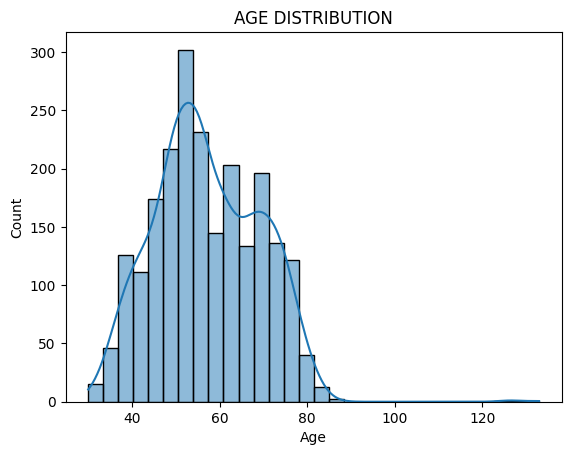

In [55]:
sns.histplot(df["Age"],bins=30,kde=True)
plt.title("AGE DISTRIBUTION")
plt.show()

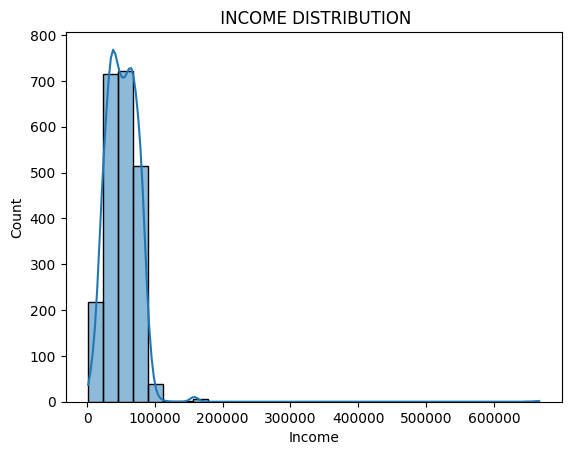

In [56]:
sns.histplot(df["Income"],bins=30,kde=True)
plt.title(" INCOME DISTRIBUTION")
plt.show()


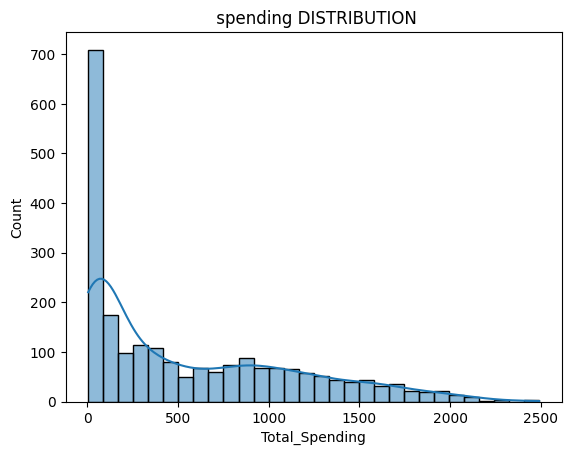

In [57]:
sns.histplot(df["Total_Spending"],bins=30,kde=True)
plt.title(" spending DISTRIBUTION")
plt.show()


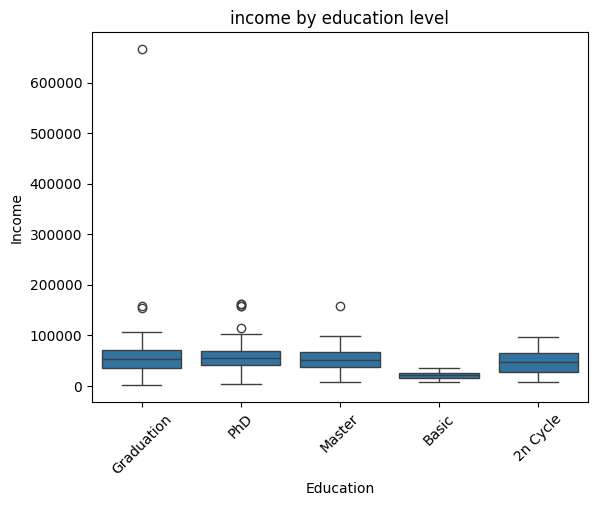

In [58]:
sns.boxplot(x="Education", y="Income",data=df)
plt.xticks(rotation=45)
plt.title("income by education level")
plt.show()

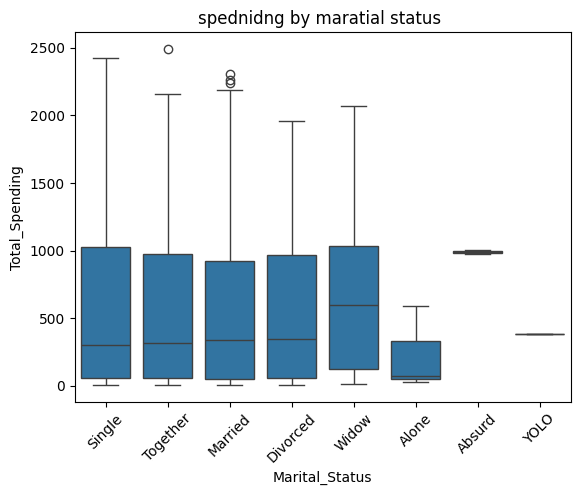

In [59]:
sns.boxplot(x="Marital_Status", y="Total_Spending",data=df)
plt.xticks(rotation=45)
plt.title("spednidng by maratial status ")
plt.show()

In [60]:
df.columns


Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_children', 'Total_Spending', 'Customer_since'],
      dtype='str')

In [61]:
corr=df[["Income","Age","Recency","Total_Spending","NumWebPurchases","NumStorePurchases"]].corr()
corr

,Income,Age,Recency,Total_Spending,NumWebPurchases,NumStorePurchases
Income,1.000000,0.161791,-0.003970,0.668062,0.387878,0.529362
Age,0.161791,1.000000,0.016295,0.112779,0.153051,0.127891
Recency,-0.003970,0.016295,1.000000,0.019374,-0.005641,-0.000434
Total_Spending,0.668062,0.112779,0.019374,1.000000,0.515999,0.670327
NumWebPurchases,0.387878,0.153051,-0.005641,0.515999,1.000000,0.516240
NumStorePurchases,0.529362,0.127891,-0.000434,0.670327,0.516240,1.000000


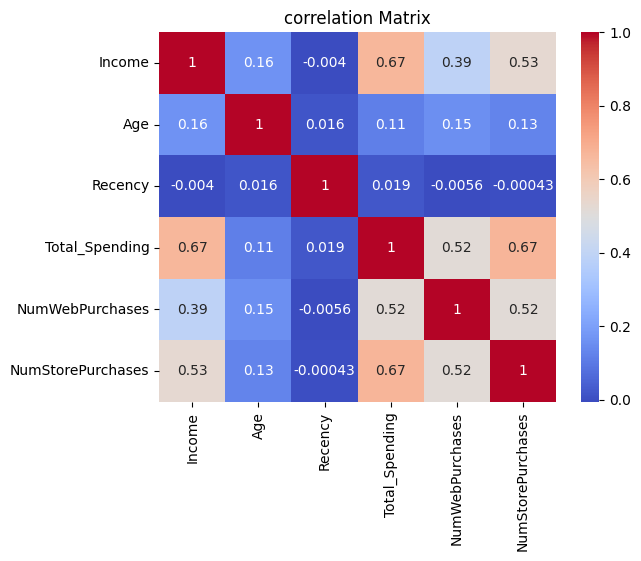

In [62]:
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("correlation Matrix")
plt.show()

In [63]:
pivot_income=df.pivot_table(values="Income",index="Education",columns="Marital_Status",aggfunc="mean")
pivot_income

Marital_Status,Absurd,Alone,Divorced,Married,Single,Together,Widow,YOLO
Education,,,,,,,,
2n Cycle,NaN,NaN,49395.130435,46201.100000,53673.944444,44736.410714,51392.200000,NaN
Basic,NaN,NaN,9548.000000,21960.500000,18238.666667,21240.071429,22123.000000,NaN
Graduation,79244.0,34176.0,54526.042017,50800.258741,51322.182927,55758.480702,54976.657143,NaN
Master,65487.0,61331.0,50331.945946,53286.028986,53530.560000,52109.009804,58401.545455,NaN
PhD,NaN,35860.0,53096.615385,58138.031579,53314.614583,56041.422414,60288.083333,48432.0


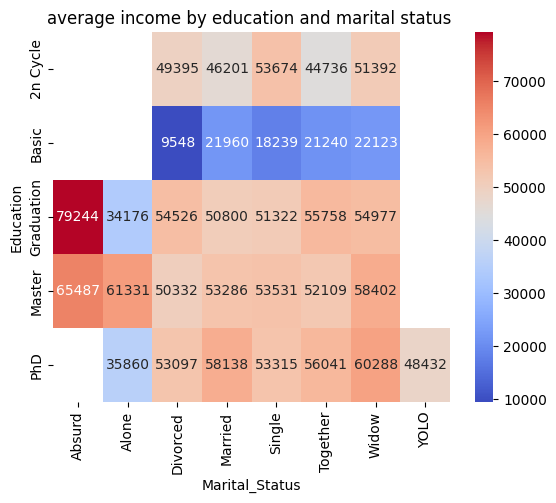

In [64]:
sns.heatmap(pivot_income,annot=True,fmt=".0f",cmap="coolwarm")
plt.title("average income by education and marital status ")
plt.show()

In [65]:
group1=df.groupby("Education")["Total_Spending"].mean().sort_values(ascending=False)
group1

Education
PhD           644.330561
Graduation    571.002688
Master        569.578082
2n Cycle      448.050000
Basic          58.962963
Name: Total_Spending, dtype: float64

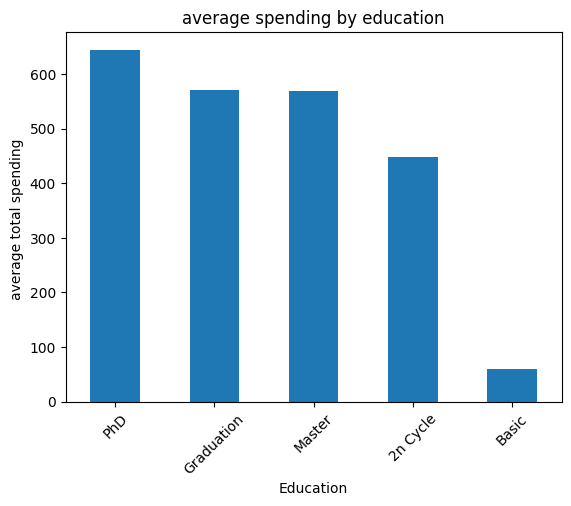

In [66]:
group1.plot(kind="bar")
plt.title("average spending by education")
plt.xticks(rotation=45)
plt.ylabel("average total spending ")
plt.show()

In [67]:
df["AcceptedAny"]=df[["AcceptedCmp1","AcceptedCmp2","AcceptedCmp3","AcceptedCmp4","AcceptedCmp5","Response"]].sum(axis=1)
df["AcceptedAny"].unique()
df["AcceptedAny"]=df["AcceptedAny"].apply(lambda x:1 if x>0 else 0)

In [68]:
group2=df.groupby("Marital_Status")["AcceptedAny"].mean().sort_values(ascending=False)
group2

Marital_Status
Absurd      0.500000
YOLO        0.500000
Widow       0.342105
Alone       0.333333
Single      0.312102
Divorced    0.297414
Married     0.252042
Together    0.251309
Name: AcceptedAny, dtype: float64

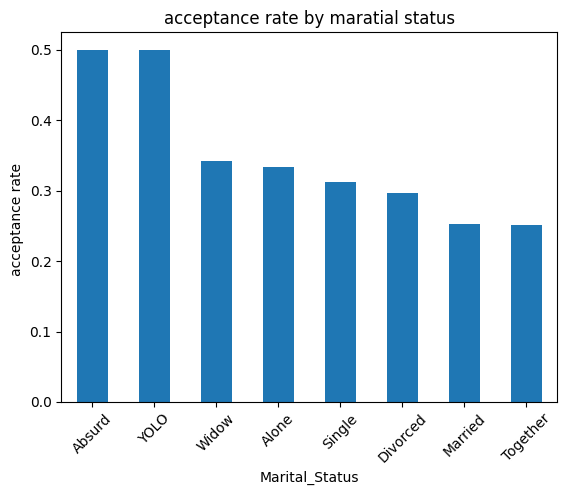

In [69]:
group2.plot(kind="bar")
plt.title("acceptance rate by maratial status")
plt.xticks(rotation=45)
plt.ylabel("acceptance rate ")
plt.show()

In [70]:
bins=[18,30,40,50,60,70,90]
labels=["18-29","30-39","40-49","50-59","60-69","70+"]


In [71]:
df["AgeGroup"]=pd.cut(df["Age"],bins=bins,labels=labels)
df["AgeGroup"]

0       60-69
1         70+
2       60-69
3       40-49
4       40-49
        ...  
2235    50-59
2236      70+
2237    40-49
2238    60-69
2239      70+
Name: AgeGroup, Length: 2216, dtype: category
Categories (6, str): ['18-29' < '30-39' < '40-49' < '50-59' < '60-69' < '70+']

In [72]:
group3=df.groupby("AgeGroup")["Income"].mean()
group3

AgeGroup
18-29    10960.500000
30-39    47905.475676
40-49    48057.587649
50-59    50479.321534
60-69    55980.030928
70+      58767.083102
Name: Income, dtype: float64

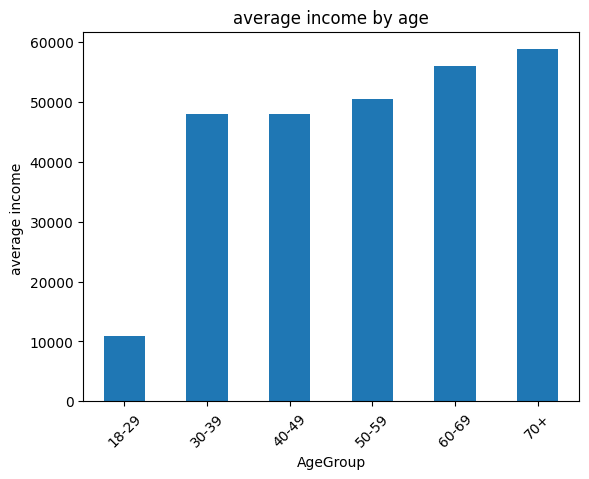

In [73]:
group3.plot(kind="bar")
plt.title("average income by age")
plt.xticks(rotation=45)
plt.ylabel("average income ")
plt.show()

In [74]:
features=["Age","Income","Total_Spending","NumWebPurchases","NumStorePurchases","Recency"]

In [75]:
x=df[features].copy()
x.head()

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,Recency
0,69,58138.0,1529,8,4,58
1,72,46344.0,21,1,2,38
2,61,71613.0,734,8,10,26
3,42,26646.0,48,2,4,26
4,45,58293.0,407,5,6,94


In [76]:
from sklearn.preprocessing import StandardScaler

In [79]:
scaler=StandardScaler()

In [81]:
x_scaled=scaler.fit_transform(x)
x_scaled

array([[ 0.98644293,  0.2340627 ,  1.67383183,  1.42855332, -0.55414289,
         0.31053212],
       [ 1.23680074, -0.23455948, -0.93944575, -1.12588116, -1.16951781,
        -0.38050944],
       [ 0.31882209,  0.76947764,  0.29614239,  1.42855332,  1.29198186,
        -0.79513438],
       ...,
       [-1.01641959,  0.18809052,  1.13315371, -0.76096195,  2.21504423,
         1.4507507 ],
       [ 1.06989553,  0.67538765,  0.37932364,  0.6987149 ,  1.29198186,
        -1.41707178],
       [ 1.23680074,  0.02470453, -0.7141632 , -0.39604274, -0.55414289,
        -0.31140528]], shape=(2216, 6))

In [82]:
from sklearn.cluster import KMeans


In [ ]:
wcss=[]
for i in range(2,10):
    kmeans=KMeans(n_clusters=i)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)
    


In [90]:
wcss

[8571.951190616728,
 7681.187001784703,
 6847.242409820828,
 6377.680577461597,
 5717.549731493786,
 5491.335496664282,
 5203.51936447275,
 4653.664909845381]

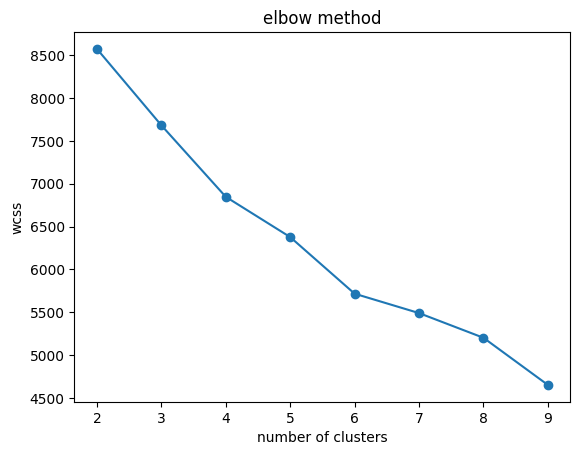

In [91]:
plt.plot(range(2,10),wcss,marker="o")
plt.title("elbow method")
plt.xlabel("number of clusters")
plt.ylabel("wcss")
plt.show()

In [92]:
kmeans=KMeans(n_clusters=6)
df["cluster"]=kmeans.fit_predict(x_scaled)

In [93]:
df.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Z_CostContact,Z_Revenue,Response,Age,Total_children,Total_Spending,Customer_since,AcceptedAny,AgeGroup,cluster
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,11,1,69,0,1529,4974,1,60-69,5
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,3,11,0,72,2,21,4424,0,70+,1
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,3,11,0,61,0,734,4623,0,60-69,5
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,3,11,0,42,1,48,4450,0,40-49,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,3,11,0,45,1,407,4472,0,40-49,3


In [94]:
cluster_summary=df.groupby("cluster")[features].mean()

In [95]:
cluster_summary

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,Recency
cluster,,,,,,
0,48.598662,77327.331104,1247.561873,5.023411,9.160535,31.270903
1,51.554455,32195.582178,72.520792,1.932673,3.045545,25.774257
2,67.967359,58308.178042,581.988131,5.151335,6.462908,26.459941
3,55.744318,36894.450758,111.130682,2.395833,3.475379,75.882576
4,63.672355,73337.402730,1201.778157,4.412969,8.778157,75.641638
5,59.645669,62134.972441,910.551181,8.980315,7.846457,59.448819


In [97]:
df["cluster"].value_counts()

cluster
3    528
1    505
2    337
0    299
4    293
5    254
Name: count, dtype: int64

In [104]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
pca_data=pca.fit_transform(x_scaled)
df["pca1"],df["pca2"]=pca_data[:,0],pca_data[:,1]


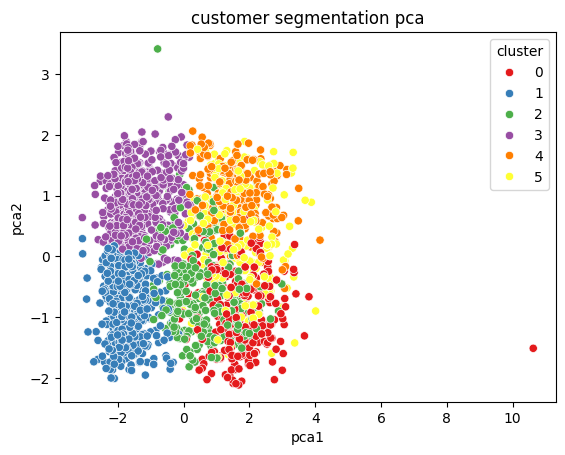

In [107]:
sns.scatterplot(x="pca1",y="pca2",hue="cluster",data =df,palette="Set1")
plt.title("customer segmentation pca")
plt.show()

In [ ]:
import joblib
joblib.dump(kmeans,"KMEANS_MODEL.PKL")
joblib.dump(scaler,"SCALER.PKL")

['SCALER.PKL']